# EDA 7 (Refined) - Alluvials for case studies

3 types telling "counter dominated London by 2021" with three main different mechanisms.

On frame C, 452 out of 982 (~46%) MSOAs are counter-led by 2021, while only ~20% are cascade-led.

The dominant transition is inner cores flipping from cascade to counter.

Three mechanisms are:
1. Persistent cascade
   Pick cascade-led both years (actually these are only 2 areas stidfying this condition), inflow-led, modest external share.
   These are flow-defined gentrification should look like.

2. Inner cascade turning counter
   There are striking patterns that areas keeping improving on IMD but still flipping to counter flow.
   These are attribute-ascending but flow-counter areas.
   They support the out-displacement arm dominated inner London.

3. Exodus
   Harrow 008 is a 2021 cascade-extreme with inflow share dropped to 1% and a large Dom A-Dom C gap;
   Harrow 029 is a counter-to-cascade flip, at D9 with cascade-inflow-share of 0.04 and external share of 0.32.
   Both areas are the COVID affluent-outflow signature, not gentrification.
   They are flase-cascade that the national frame manufactures.

**Changes vs v1:**
1. DIRECTION is drawn, not captioned:
   - 'INFLOWS >>' / '>> OUTFLOWS' headers over each half
   - white chevron arrows inside every ribbon, all pointing rightward
     (flow passes left-to-right THROUGH the MSOA bar)
   - each arm carries its own origin/destination label
     ('from wealthier areas', 'to poorer areas', ...)
2. EXTERNAL volume is drawn spatially, not just tinted:
   - dashed vertical 'London boundary' lines on both sides
   - internal ribbons start/stop AT the boundary
   - external ribbons physically CROSS it into a shaded
     'rest of England' margin -> their width outside the line
     IS the external volume
3. Geography chip: small 'Inner/Outer London . national decile' badge
   per panel (placeholder for a proper locator map).

In every panel:
- inflows enter on the left, outflows exit on the right
- ribbon width is proportional to people volume
    - Red is cascade arms
        - inflow from wealthier 
        - outflow to poorer
    - Purple is counter arms
        - inflow from poorer
        - outflow to wealthier

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
from matplotlib.patches import PathPatch
 
plt.rcParams['font.family'] = 'DejaVu Sans'
from pyprojroot import here

In [2]:

ROOT       = here()
sys.path.insert(0, str(ROOT))

DATA_DIR   = ROOT / 'data'
OUT_DIR    = ROOT / 'outputs' / 'case_study'
NAT  = ROOT / 'outputs'/'msoa_cascade_national_frame_20260625.csv'
EDA4 = ROOT / 'outputs'/'eda4_results_for_phase3_20260626.csv'
EXT_DECILE = 6                                   # synthetic external node sits at national D6
YL = 3.05

OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
C_IN, C_EX = '#c0392b', '#e8a7a0'
K_IN, K_EX = '#6a51a3', '#bcaede'
BAR  = '#2f2f2f'
ZONE = '#f2f0ec'          # rest-of-England margin shading
BND  = '#8a8a8a'          # boundary dash colour

In [4]:
# ── x-geometry ──────────────────────────────────────────────────────────
X_EXT_L = -1.05   # external ribbons start here (left)
X_BND_L =  0.30   # London boundary, left
X_ML    =  3.30   # MSOA bar left edge
X_MR    =  3.90   # MSOA bar right edge
X_BND_R =  6.90   # London boundary, right
X_EXT_R =  8.25   # external ribbons end here (right)
 
INNER_LONDON = {
    'Camden','City of London','Greenwich','Hackney','Hammersmith and Fulham',
    'Haringey','Islington','Kensington and Chelsea','Lambeth','Lewisham',
    'Newham','Southwark','Tower Hamlets','Wandsworth','Westminster',
}

In [5]:
def _band(ax, x0, x1, lo, hi, color):
    ax.add_patch(mpatches.Rectangle((x0, lo), x1-x0, hi-lo,
                                    facecolor=color, edgecolor='none',
                                    alpha=0.92, zorder=3))

In [6]:
def _chevron(ax, xc, yc, h):
    """White right-pointing chevron centred at (xc, yc); h = band height."""
    s = min(h*0.55, 0.14)
    if s < 0.045: return
    w = s * 0.9
    verts = [(xc-w/2, yc+s), (xc+w/2, yc), (xc-w/2, yc-s),
             (xc-w/2+w*0.45, yc), (xc-w/2, yc+s)]
    ax.add_patch(PathPatch(Path(verts, closed=True), facecolor='white',
                           edgecolor='none', alpha=0.85, zorder=4))

In [7]:
def _lay(segs, gap, scale):
    hs = [(v/scale, c, n, x0, x1) for v, c, n, x0, x1 in segs]
    tot = sum(h for h, *_ in hs) + gap*(sum(1 for _, _, n, _, _ in hs if n) - 1)
    top = tot/2; out = []
    for i, (h, c, n, x0, x1) in enumerate(hs):
        if n and i > 0: top -= gap
        out.append((top-h, top, c, x0, x1)); top -= h
    return out

In [8]:
def arms_split(r, yr):
    d  = r['Wealth_Decile_National']
    ei, eo = r[f'Ext_Inflow_nat_{yr}'], r[f'Ext_Outflow_nat_{yr}']
    iw, op = r[f'Inflow_Wealthier_nat_{yr}'], r[f'Outflow_Poorer_nat_{yr}']
    ip, ow = r[f'Inflow_Poorer_nat_{yr}'],    r[f'Outflow_Wealthier_nat_{yr}']
    e_iw = ei if d < EXT_DECILE else 0; e_ip = ei if d > EXT_DECILE else 0
    e_ow = eo if d < EXT_DECILE else 0; e_op = eo if d > EXT_DECILE else 0
    return dict(iw=iw, op=op, ip=ip, ow=ow, iw_e=e_iw, op_e=e_op, ip_e=e_ip, ow_e=e_ow,
                iw_i=iw-e_iw, op_i=op-e_op, ip_i=ip-e_ip, ow_i=ow-e_ow)

In [9]:
def panel(ax, r, yr, scale, title, dom_lon, show_headers=True):
    a = arms_split(r, yr); gap = 0.30
 
    # background: rest-of-England margins + boundary dashes
    ax.add_patch(mpatches.Rectangle((X_EXT_L-0.55, -YL), X_BND_L-(X_EXT_L-0.55), 2*YL,
                                    facecolor=ZONE, edgecolor='none', zorder=0))
    ax.add_patch(mpatches.Rectangle((X_BND_R, -YL), (X_EXT_R+0.55)-X_BND_R, 2*YL,
                                    facecolor=ZONE, edgecolor='none', zorder=0))
    for xb in (X_BND_L, X_BND_R):
        ax.plot([xb, xb], [-YL*0.88, YL*0.80], ls=(0,(4,3)), lw=0.9, color=BND, zorder=1)
    ax.text(X_BND_L, -YL*0.96, 'London boundary', ha='center', va='top',
            fontsize=5.8, color=BND)
    ax.text(X_BND_R, -YL*0.96, 'London boundary', ha='center', va='top',
            fontsize=5.8, color=BND)
    ax.text((X_EXT_L-0.55+X_BND_L)/2, -YL*0.80, 'rest of\nEngland', ha='center',
            va='center', fontsize=5.8, color='#9a9a9a', style='italic')
    ax.text((X_BND_R+X_EXT_R+0.55)/2, -YL*0.80, 'rest of\nEngland', ha='center',
            va='center', fontsize=5.8, color='#9a9a9a', style='italic')
 
    # segments now carry their own x-extent: internal stops at the boundary,
    # external crosses it
    Lsegs = [(a['iw_i'], C_IN, True,  X_BND_L, X_ML),
             (a['iw_e'], C_EX, False, X_EXT_L, X_ML),
             (a['ip_i'], K_IN, True,  X_BND_L, X_ML),
             (a['ip_e'], K_EX, False, X_EXT_L, X_ML)]
    Rsegs = [(a['ow_i'], K_IN, True,  X_MR, X_BND_R),
             (a['ow_e'], K_EX, False, X_MR, X_EXT_R),
             (a['op_i'], C_IN, True,  X_MR, X_BND_R),
             (a['op_e'], C_EX, False, X_MR, X_EXT_R)]
    L, R = _lay(Lsegs, gap, scale), _lay(Rsegs, gap, scale)
 
    for lo, hi, c, x0, x1 in L:
        _band(ax, x0, x1, lo, hi, c)
        _chevron(ax, X_ML-0.55, (lo+hi)/2, hi-lo)          # arrows into the bar
    for lo, hi, c, x0, x1 in R:
        _band(ax, x0, x1, lo, hi, c)
        _chevron(ax, x1-0.45, (lo+hi)/2, hi-lo)            # arrows exiting
 
    bar_lo, bar_hi = min(L[-1][0], R[-1][0]), max(L[0][1], R[0][1])
    ax.add_patch(mpatches.Rectangle((X_ML, bar_lo), X_MR-X_ML, bar_hi-bar_lo,
                                    facecolor=BAR, edgecolor='none', zorder=5))
 
    # arm labels + counts, anchored at the OUTER end of each arm
    iw_c=(L[0][0]+L[1][1])/2; ip_c=(L[2][0]+L[3][1])/2
    ow_c=(R[0][0]+R[1][1])/2; op_c=(R[2][0]+R[3][1])/2
    def lab(x, y, name, tot, ext, c, ha):
        if tot/scale < 0.03: return
        ax.text(x, y+0.085, name, ha=ha, va='bottom', fontsize=6.4,
                color=c, fontweight='bold')
        ax.text(x, y-0.075, f'{int(tot)}'+(f' (ext {int(ext)})' if ext > 0.5 else ''),
                ha=ha, va='top', fontsize=6.8, color=c)
    lab(X_EXT_L-0.68, iw_c, 'from wealthier', a['iw'], a['iw_e'], C_IN, 'right')
    lab(X_EXT_L-0.68, ip_c, 'from poorer',    a['ip'], a['ip_e'], K_IN, 'right')
    lab(X_EXT_R+0.68, ow_c, 'to wealthier',   a['ow'], a['ow_e'], K_IN, 'left')
    lab(X_EXT_R+0.68, op_c, 'to poorer',      a['op'], a['op_e'], C_IN, 'left')
 
    # direction headers, drawn on the plot itself
    if show_headers:
        ax.text((X_EXT_L+X_ML)/2, YL*0.90, 'I N F L O W S  \u25b6',
                ha='center', va='center', fontsize=7.6, color='#555',
                fontweight='bold')
        ax.text((X_MR+X_EXT_R)/2, YL*0.90, '\u25b6  O U T F L O W S',
                ha='center', va='center', fontsize=7.6, color='#555',
                fontweight='bold')
 
    # geography chip: ring + national decile
    ring = 'Inner' if r['ladnm'] in INNER_LONDON else 'Outer'
    ax.text(0.99, 0.985, f"{ring} London \u00b7 nat D{int(r['Wealth_Decile_National'])}",
            transform=ax.transAxes, ha='right', va='top', fontsize=6.6,
            color='#444',
            bbox=dict(boxstyle='round,pad=0.32', fc='white', ec='#cfcfcf', lw=0.7))
 
    casc, cnt = a['iw']+a['op'], a['ip']+a['ow']; dom = casc/(casc+cnt)
    infl = a['iw']/(a['iw']+a['op']) if (a['iw']+a['op']) else np.nan
    ext_sh = (a['iw_e']+a['ip_e']+a['ow_e']+a['op_e'])/(casc+cnt) if (casc+cnt) else 0
    ax.text(0.5, -0.045, f'dominance(nat) {dom:.2f}   inflow share {infl:.2f}   '
            f'external {ext_sh:.0%}   \u00b7   dominance(London) {dom_lon:.2f}',
            transform=ax.transAxes, ha='center', va='top', fontsize=8,
            color=C_IN if dom >= 0.5 else K_IN, fontweight='bold')
    ax.text(0.5, 1.0, title, transform=ax.transAxes, ha='center', va='bottom',
            fontsize=10, fontweight='bold')
    ax.set_xlim(X_EXT_L-2.55, X_EXT_R+2.55); ax.set_ylim(-YL, YL)
    ax.set_axis_off()

In [10]:
nat = pd.read_csv(NAT); e4 = pd.read_csv(EDA4)
domA = lambda c, yr: e4.loc[e4['msoa11cd']==c, f'Dom_A_{yr}'].iloc[0]
row  = lambda c: nat[nat['msoa11cd']==c].iloc[0]

In [11]:
def figscale(cases):
    m = 0
    for c, _ in cases:
        r = row(c)
        for yr in ['11','21']:
            a = arms_split(r, yr); m = max(m, a['iw']+a['ip'], a['ow']+a['op'])
    return m/3.0

In [12]:
LEG = [mpatches.Patch(color=C_IN, label='Cascade · within London'),
       mpatches.Patch(color=C_EX, label='Cascade · London - rest of England'),
       mpatches.Patch(color=K_IN, label='Counter · within London'),
       mpatches.Patch(color=K_EX, label='Counter · London - rest of England')]

In [ ]:
# def build(title, cases, fname, caption):
#     sc = figscale(cases); nr = len(cases)
#     fig, axes = plt.subplots(nr, 2, figsize=(13, 3.0*nr+1.6), squeeze=False)
#     for i, (c, n) in enumerate(cases):
#         panel(axes[i,0], row(c), '11', sc, f'{n}  ·  2011', domA(c,'11'))
#         panel(axes[i,1], row(c), '21', sc, f'{n}  ·  2021', domA(c,'21'))
#     fig.suptitle(title, fontsize=13.5, fontweight='bold', y=0.995)
#     fig.legend(handles=LEG, loc='lower center', ncol=2, frameon=False, fontsize=8.4, bbox_to_anchor=(0.5,0.004))
#     fig.text(0.5, 0.055, 'Inflows enter on the left, outflows exit on the right.  ' + caption,
#              ha='center', va='bottom', fontsize=8.2, style='italic', color='#333', wrap=True)
#     plt.tight_layout(rect=[0,0.085,1,0.97]); plt.savefig(OUT_DIR / fname, dpi=130, bbox_inches='tight'); plt.show()

In [13]:
# ── build(): same call signature as before; captions can now shrink ──────
def build(title, cases, fname, caption=''):
    sc = figscale(cases); nr = len(cases)
    fig, axes = plt.subplots(nr, 2, figsize=(14, 3.4*nr+1.4), squeeze=False)
    for i, (c, n) in enumerate(cases):
        panel(axes[i,0], row(c), '11', sc, f'{n}  ·  2011', domA(c,'11'), show_headers=(i==0))
        panel(axes[i,1], row(c), '21', sc, f'{n}  ·  2021', domA(c,'21'), show_headers=(i==0))
    fig.suptitle(title, fontsize=13.5, fontweight='bold', y=0.995)
    fig.legend(handles=LEG, loc='lower center', ncol=4, frameon=False, fontsize=8.4,
               bbox_to_anchor=(0.5, 0.006))
    if caption:
        fig.text(0.5, 0.048, caption, ha='center', va='bottom', fontsize=8.2,
                 style='italic', color='#333', wrap=True)
    plt.tight_layout(rect=[0, 0.07 if caption else 0.035, 1, 0.975])
    plt.savefig(OUT_DIR / fname, dpi=130, bbox_inches='tight'); plt.show()
 
LEG = [mpatches.Patch(color=C_IN, label='Cascade · within London'),
       mpatches.Patch(color=C_EX, label='Cascade · crossing London boundary'),
       mpatches.Patch(color=K_IN, label='Counter · within London'),
       mpatches.Patch(color=K_EX, label='Counter · crossing London boundary')]

In [14]:
def figscale(cases):
    m = 0
    for c, _ in cases:
        r = row(c)
        for yr in ['11','21']:
            a = arms_split(r, yr); m = max(m, a['iw']+a['ip'], a['ow']+a['op'])
    return m/3.0

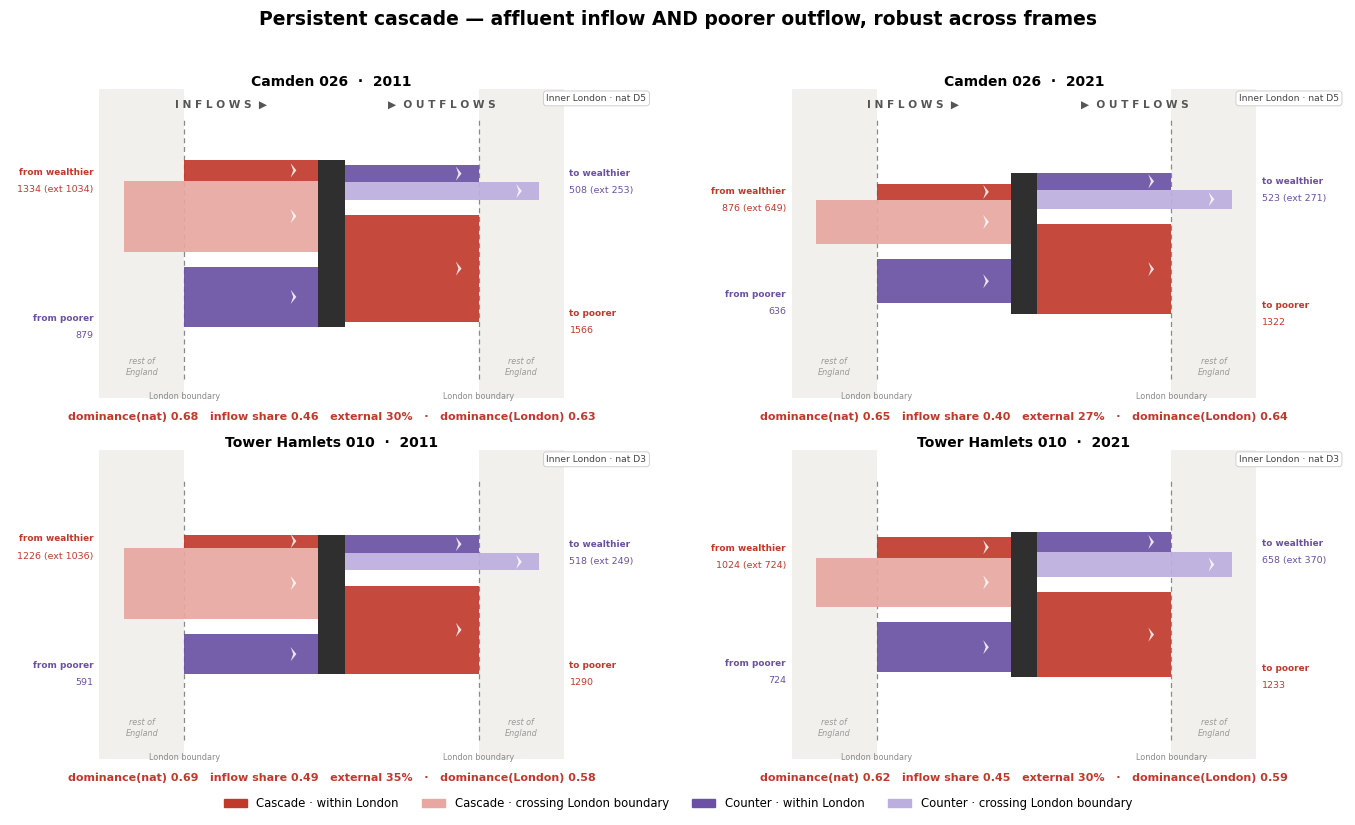

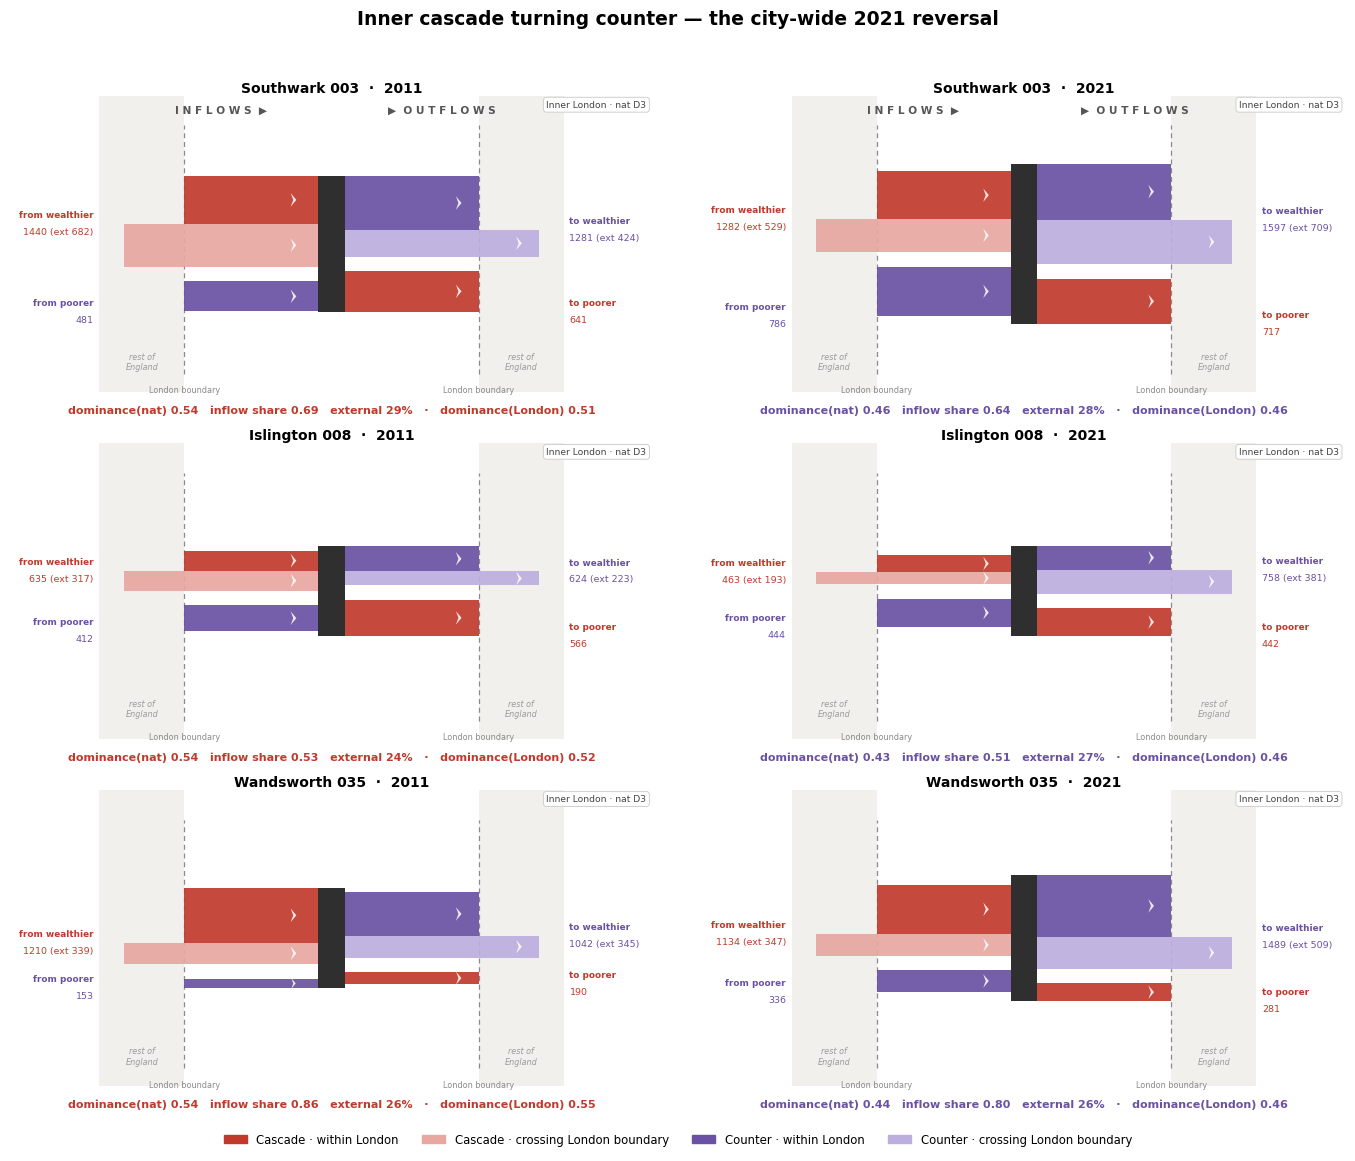

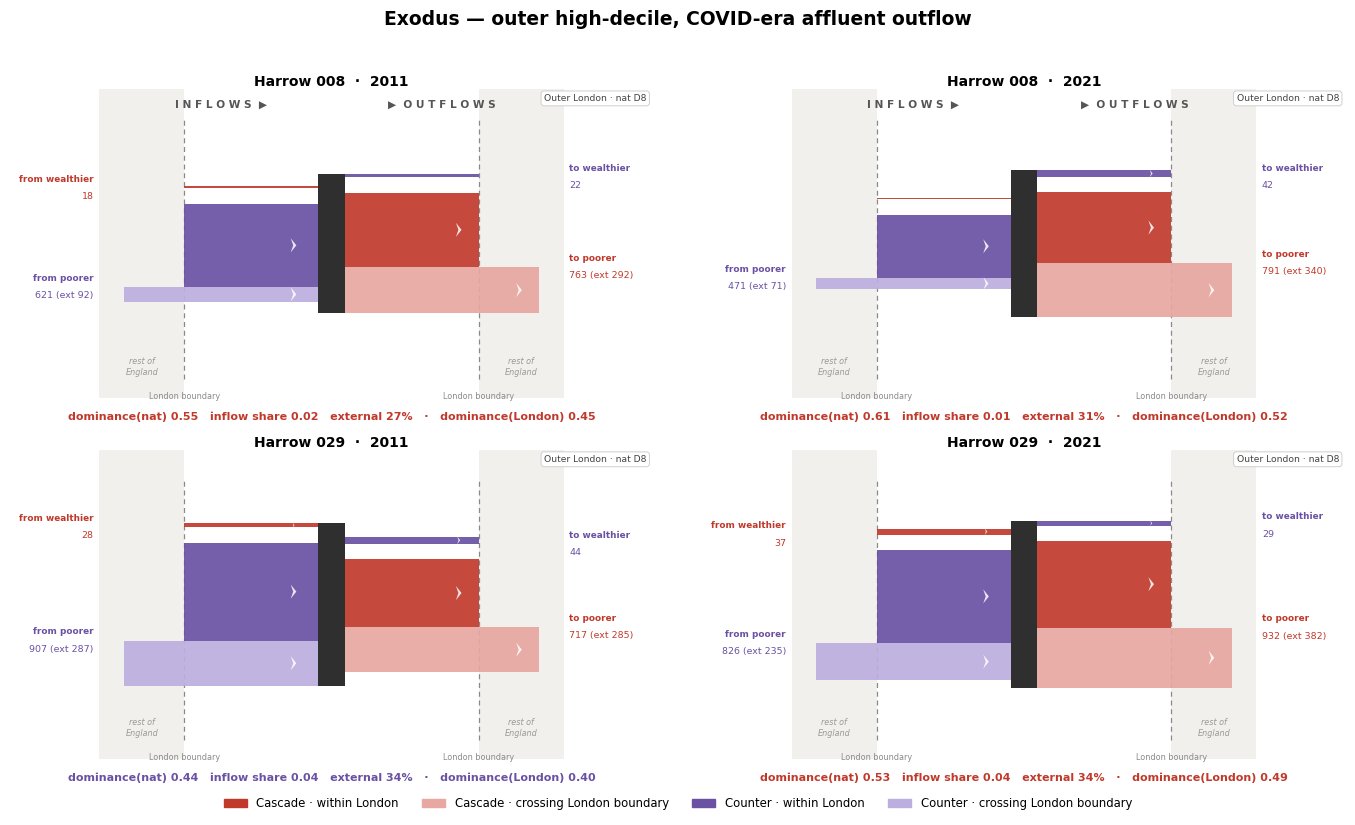

In [16]:


build('Persistent cascade — affluent inflow AND poorer outflow, robust across frames',
      [('E02000191','Camden 026'),('E02000873','Tower Hamlets 010')],
      'fig_case_A_persistent_cascade.png')
      # 'Affluent-IN (red, left) and poorer-OUT (red, right) are both thick and the national/London dominance gap is small. '
      # 'Light-red on the inflow arm shows most affluent in-migration arrives from outside London —-> a real gentrification cascade.')
 
build('Inner cascade turning counter — the city-wide 2021 reversal',
      [('E02000809','Southwark 003'),('E02000561','Islington 008'),('E02000957','Wandsworth 035')],
      'fig_case_B_cascade_to_counter.png')
      # 'These inner cores keep improving on IMD yet the FLOW balance tips from red (cascade) to purple (counter) by 2021: '
      # 'the affluent-OUT / poorer-IN arms grow relative to the cascade arms (dominance crosses 0.50; the figure colour flips).')
 
build('Exodus — outer high-decile, COVID-era affluent outflow',
      [('E02000440','Harrow 008'),('E02000461','Harrow 029')],
      'fig_case_C_exodus.png')
      # 'The affluent-inflow arm is a bare thread (inflow share ~0.01-0.04). The cascade is almost all poorer-OUTflow, much of it '
      # 'light-red London->outside moves. National frame reads cascade, London frame reads neutral/counter — the gap is the exodus signature.')